In [ ]:
import sys
from pathlib import Path


NOTEBOOK_DIR = Path().resolve()
TRAIN_DIR = NOTEBOOK_DIR / "train"
MODELS_DIR = NOTEBOOK_DIR / "models"
if str(TRAIN_DIR) not in sys.path:
    sys.path.append(str(TRAIN_DIR))
if str(MODELS_DIR) not in sys.path:
    sys.path.append(str(MODELS_DIR))

from dataset_spacenet import SpaceNetDataset
from hrnet_w48_sn7 import HRNetW48

Total patches in split 'test': 10246
Evaluating test patch index: 8346


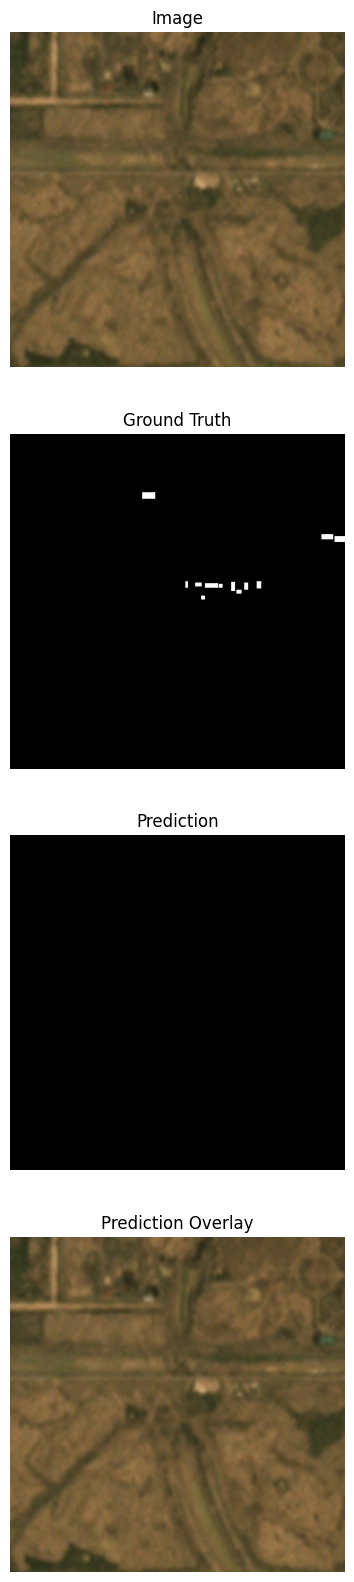

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import random
from pathlib import Path

from dataset_spacenet import SpaceNetDataset
from hrnet_w48_sn7 import HRNetW48




device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = HRNetW48(in_channels=4, num_classes=2)


NOTEBOOK_DIR = Path().resolve()

ckpt_path = NOTEBOOK_DIR / "train" / "checkpoints" / "latest.pth"

if not ckpt_path.exists():
    raise FileNotFoundError(
        f"Checkpoint not found at {ckpt_path}.\n"
        "Either train a model with train/train_hrnet_sn7.py "
        "(it will save to train/checkpoints/latest.pth), or update ckpt_path "
        "to point to an existing .pth file."
    )

checkpoint = torch.load(ckpt_path, map_location=device)

model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()



root = "../data/SN7_buildings_train/train"

SPLIT_DIR = NOTEBOOK_DIR / "splits"

dataset = SpaceNetDataset(str(root), split="test", split_list_dir=str(SPLIT_DIR))


random.seed()
idx = random.randint(0, len(dataset) - 1)
print(f"Evaluating test patch index: {idx}")
image, mask = dataset[idx]

image_t = image.unsqueeze(0).to(device)

with torch.no_grad():

    pred = model(image_t)

    pred = torch.nn.functional.interpolate(
        pred,
        size=(512,512),
        mode="bilinear",
        align_corners=False
    )

    pred = torch.softmax(pred, dim=1)
    pred = pred.argmax(1).cpu().numpy()[0]


image_np = image.numpy().transpose(1,2,0)
mask_np = mask.numpy()



fig, axes = plt.subplots(4,1,figsize=(10,20))

axes[0].imshow(image_np[:,:,:3])
axes[0].set_title("Image")

axes[1].imshow(mask_np, cmap="gray")
axes[1].set_title("Ground Truth")

axes[2].imshow(pred, cmap="gray")
axes[2].set_title("Prediction")

overlay = image_np[:,:,:3].copy()
overlay[pred==1] = [255,0,0]

axes[3].imshow(overlay)
axes[3].set_title("Prediction Overlay")

for ax in axes:
    ax.axis("off")

plt.show()

Evaluating Full Image: global_monthly_2020_01_mosaic_L15-1481E-1119N_5927_3715_13.tif from L15-1481E-1119N_5927_3715_13


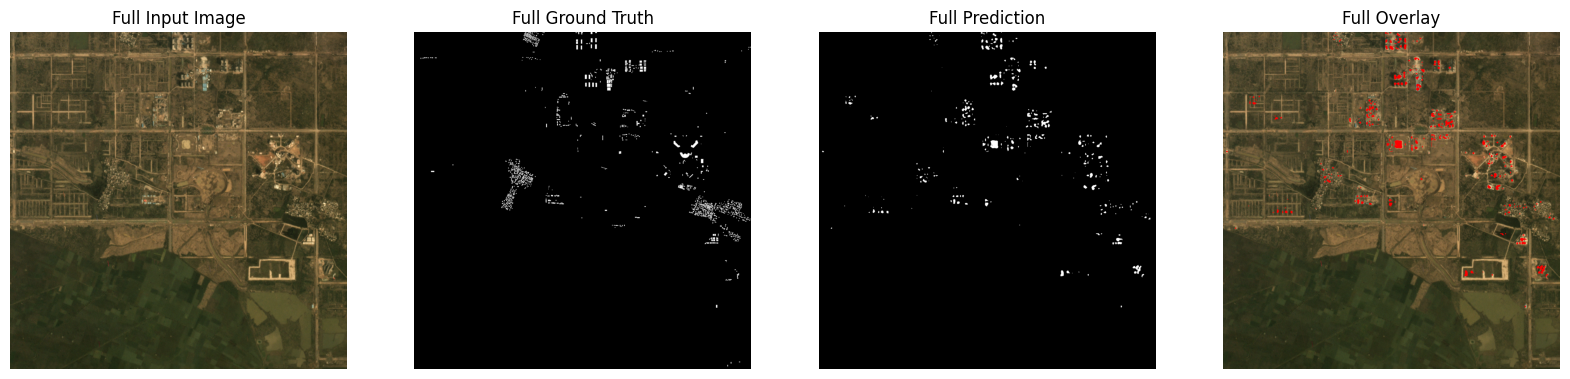

In [9]:

import os
import re


sample_patch = dataset.samples[idx][0] 

path_parts = sample_patch.split(os.sep)
aoi = path_parts[-3]
patch_filename = path_parts[-1]

orig_filename = re.sub(r"_\d{5}_\d{5}\.tif$", ".tif", patch_filename)

orig_img_path = os.path.join(root, aoi, "images_masked", orig_filename)
orig_mask_path = os.path.join(root, aoi, "masks_3x", orig_filename)

if not os.path.exists(orig_mask_path):
    print(f"Ground truth not found: {orig_mask_path}")
else:
    print(f"Evaluating Full Image: {orig_filename} from {aoi}")
    with rasterio.open(orig_img_path) as src:
        orig_image = src.read()[:4].astype(np.float32) / 255.0
    with rasterio.open(orig_mask_path) as src:
        orig_mask = src.read(1).astype(np.int64)

    image_t = torch.from_numpy(orig_image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image_t)
  
        pred = torch.nn.functional.interpolate(
            pred, size=(orig_image.shape[1], orig_image.shape[2]), mode="bilinear", align_corners=False
        )
        pred = torch.softmax(pred, dim=1).argmax(1).cpu().numpy()[0]

  
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    img_display = orig_image[:3].transpose(1, 2, 0)
    
    axes[0].imshow(img_display)
    axes[0].set_title("Full Input Image")
    
    axes[1].imshow(orig_mask, cmap="gray")
    axes[1].set_title("Full Ground Truth")

    axes[2].imshow(pred, cmap="gray")
    axes[2].set_title("Full Prediction")

    overlay = img_display.copy()
  
    overlay[pred == 1] = [1, 0, 0] 
    axes[3].imshow(overlay)
    axes[3].set_title("Full Overlay")

    for ax in axes: ax.axis("off")

    plt.show()